In [1]:
# ============================================
# CUSTOMER LIFETIME VALUE PREDICTION
# Intermediate Level Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression  # Baseline

# Clustering for segmentation
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("="*60)
print("CUSTOMER LIFETIME VALUE PREDICTION")
print("="*60)

CUSTOMER LIFETIME VALUE PREDICTION


In [2]:
# Load datasets
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print("\n=== First 5 rows of training data ===")
df_train.head()

Training set: (9806, 22)
Test set: (1767, 21)

=== First 5 rows of training data ===


,CustomerID,Customer.Lifetime.Value,Coverage,Education,EmploymentStatus,Gender,Income,Location.Geo,Location.Code,Marital.Status,...,Months.Since.Policy.Inception,Number.of.Open.Complaints,Number.of.Policies,Policy.Type,Policy,Renew.Offer.Type,Sales.Channel,Total.Claim.Amount,Vehicle.Class,Vehicle.Size
0,5917,7824.372789,Basic,Bachelor,Unemployed,F,0,"17.7,77.7",Urban,Married,...,33,NaN,2.0,Personal Auto,Personal L2,Offer2,Branch,267.214383,Four-Door Car,2.0
1,2057,8005.964669,Basic,College,Employed,M,63357,"28.8,76.6",Suburban,Married,...,42,0.0,5.0,Personal Auto,Personal L2,Offer2,Agent,565.508572,SUV,2.0
2,4119,8646.504109,Basic,High School or Below,Employed,F,64125,"21.6,88.4",Urban,Married,...,44,0.0,3.0,Personal Auto,Personal L1,Offer2,Branch,369.818708,SUV,1.0
3,1801,9294.088719,Basic,College,Employed,M,67544,"19,72.5",Suburban,Married,...,15,NaN,3.0,Corporate Auto,Corporate L3,Offer1,Branch,556.800000,SUV,3.0
4,9618,5595.971365,Basic,Bachelor,Retired,F,19651,"19.1,74.7",Suburban,Married,...,68,0.0,5.0,Personal Auto,Personal L1,Offer2,Web,345.600000,Two-Door Car,3.0


In [3]:

# DATA CLEANING FUNCTION


def clean_insurance_data(df, is_train=True):
    """
    Clean insurance dataset for CLV prediction
    """
    df_clean = df.copy()
    
    # 1. Handle missing/invalid values in Customer.Lifetime.Value (only for train)
    if is_train and 'Customer.Lifetime.Value' in df_clean.columns:
        # Remove rows where CLV is missing or invalid
        df_clean = df_clean[df_clean['Customer.Lifetime.Value'].notna()]
        df_clean = df_clean[df_clean['Customer.Lifetime.Value'] > 0]
    
    # 2. Clean Income column
    df_clean['Income'] = df_clean['Income'].replace(['NA', '?', ''], np.nan)
    df_clean['Income'] = pd.to_numeric(df_clean['Income'], errors='coerce')
    # Replace 0 income with NaN (likely missing data)
    df_clean.loc[df_clean['Income'] == 0, 'Income'] = np.nan
    
    # 3. Clean numeric columns
    numeric_cols = ['Monthly.Premium.Auto', 'Months.Since.Last.Claim', 
                    'Months.Since.Policy.Inception', 'Number.of.Open.Complaints',
                    'Number.of.Policies', 'Total.Claim.Amount']
    
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    #  Fix Number.of.Open.Complaints (had 'NA' values)
    df_clean['Number.of.Open.Complaints'] = df_clean['Number.of.Open.Complaints'].replace('NA', 0)
    df_clean['Number.of.Open.Complaints'] = pd.to_numeric(df_clean['Number.of.Open.Complaints'], errors='coerce').fillna(0)
    
    #  Extract location features from Location.Geo
    if 'Location.Geo' in df_clean.columns:
        location_split = df_clean['Location.Geo'].str.split(',', expand=True)
        df_clean['Latitude'] = pd.to_numeric(location_split[0], errors='coerce')
        df_clean['Longitude'] = pd.to_numeric(location_split[1], errors='coerce')
    
    # Clean Vehicle.Size - convert 1,2,3 to categories
    if 'Vehicle.Size' in df_clean.columns:
        size_map = {'1': 'Small', '2': 'Medsize', '3': 'Large', 
                    'Small': 'Small', 'Medsize': 'Medsize', 'Large': 'Large'}
        df_clean['Vehicle.Size'] = df_clean['Vehicle.Size'].map(size_map).fillna('Medsize')
    
    #  Clean categorical columns
    categorical_cols = ['Coverage', 'Education', 'EmploymentStatus', 'Gender', 
                        'Location.Code', 'Marital.Status', 'Policy.Type', 
                        'Policy', 'Renew.Offer.Type', 'Sales.Channel', 
                        'Vehicle.Class', 'Vehicle.Size']
    
    for col in categorical_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].replace(['NA', '?', ''], 'Unknown')
            df_clean[col] = df_clean[col].fillna('Unknown')
    
    #  Create derived features
    # Recency: Months since last claim (lower is more recent activity)
    df_clean['Recency'] = df_clean['Months.Since.Last.Claim'].clip(0, 60)
    
    # Tenure: Months since policy inception
    df_clean['Tenure_Months'] = df_clean['Months.Since.Policy.Inception'].clip(0, 120)
    
    # Customer activity score (lower months since claim is better)
    df_clean['Activity_Score'] = 1 / (df_clean['Months.Since.Last.Claim'] + 1)
    
    # Claims ratio (claims vs premiums)
    df_clean['Claim_to_Premium_Ratio'] = df_clean['Total.Claim.Amount'] / (df_clean['Monthly.Premium.Auto'] + 1)
    
    # Complaint indicator
    df_clean['Has_Complaint'] = (df_clean['Number.of.Open.Complaints'] > 0).astype(int)
    
    # Policy count category
    df_clean['Multi_Policy'] = (df_clean['Number.of.Policies'] > 3).astype(int)
    
    # . Drop columns with too many missing values or not useful
    cols_to_drop = ['CustomerID', 'Location.Geo']
    cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    return df_clean

# Apply cleaning
df_train_clean = clean_insurance_data(df_train, is_train=True)
df_test_clean = clean_insurance_data(df_test, is_train=False)

print(f"Cleaned training set: {df_train_clean.shape}")
print(f"Cleaned test set: {df_test_clean.shape}")
print("\n=== Missing values after cleaning ===")
print(df_train_clean.isnull().sum()[df_train_clean.isnull().sum() > 0])

Cleaned training set: (9806, 28)
Cleaned test set: (1767, 27)

=== Missing values after cleaning ===
Income                    2579
Monthly.Premium.Auto       794
Number.of.Policies         121
Latitude                   119
Longitude                  119
Claim_to_Premium_Ratio     794
dtype: int64


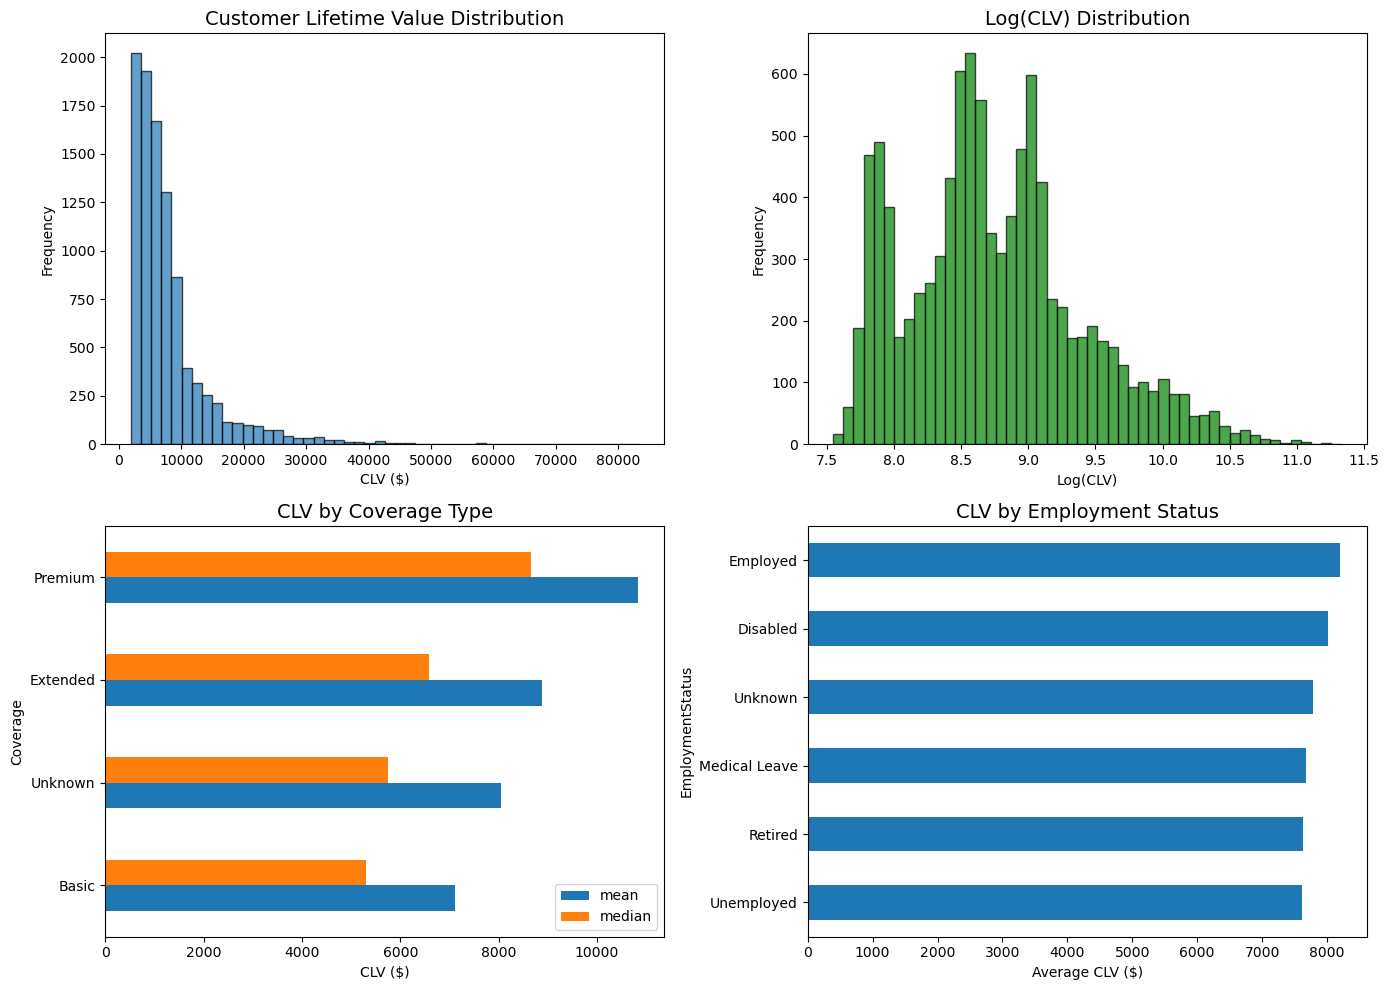

In [4]:

# EDA - Understanding CLV Distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CLV Distribution
ax1 = axes[0, 0]
ax1.hist(df_train_clean['Customer.Lifetime.Value'], bins=50, edgecolor='black', alpha=0.7)
ax1.set_title('Customer Lifetime Value Distribution', fontsize=14)
ax1.set_xlabel('CLV ($)')
ax1.set_ylabel('Frequency')

# Log transform for better visualization
ax2 = axes[0, 1]
ax2.hist(np.log1p(df_train_clean['Customer.Lifetime.Value']), bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.set_title('Log(CLV) Distribution', fontsize=14)
ax2.set_xlabel('Log(CLV)')
ax2.set_ylabel('Frequency')

# CLV by Coverage Type
ax3 = axes[1, 0]
coverage_clv = df_train_clean.groupby('Coverage')['Customer.Lifetime.Value'].agg(['mean', 'median'])
coverage_clv.sort_values('mean').plot(kind='barh', ax=ax3)
ax3.set_title('CLV by Coverage Type', fontsize=14)
ax3.set_xlabel('CLV ($)')

# CLV by Employment Status
ax4 = axes[1, 1]
emp_clv = df_train_clean.groupby('EmploymentStatus')['Customer.Lifetime.Value'].mean().sort_values()
emp_clv.plot(kind='barh', ax=ax4)
ax4.set_title('CLV by Employment Status', fontsize=14)
ax4.set_xlabel('Average CLV ($)')

plt.tight_layout()
plt.show()

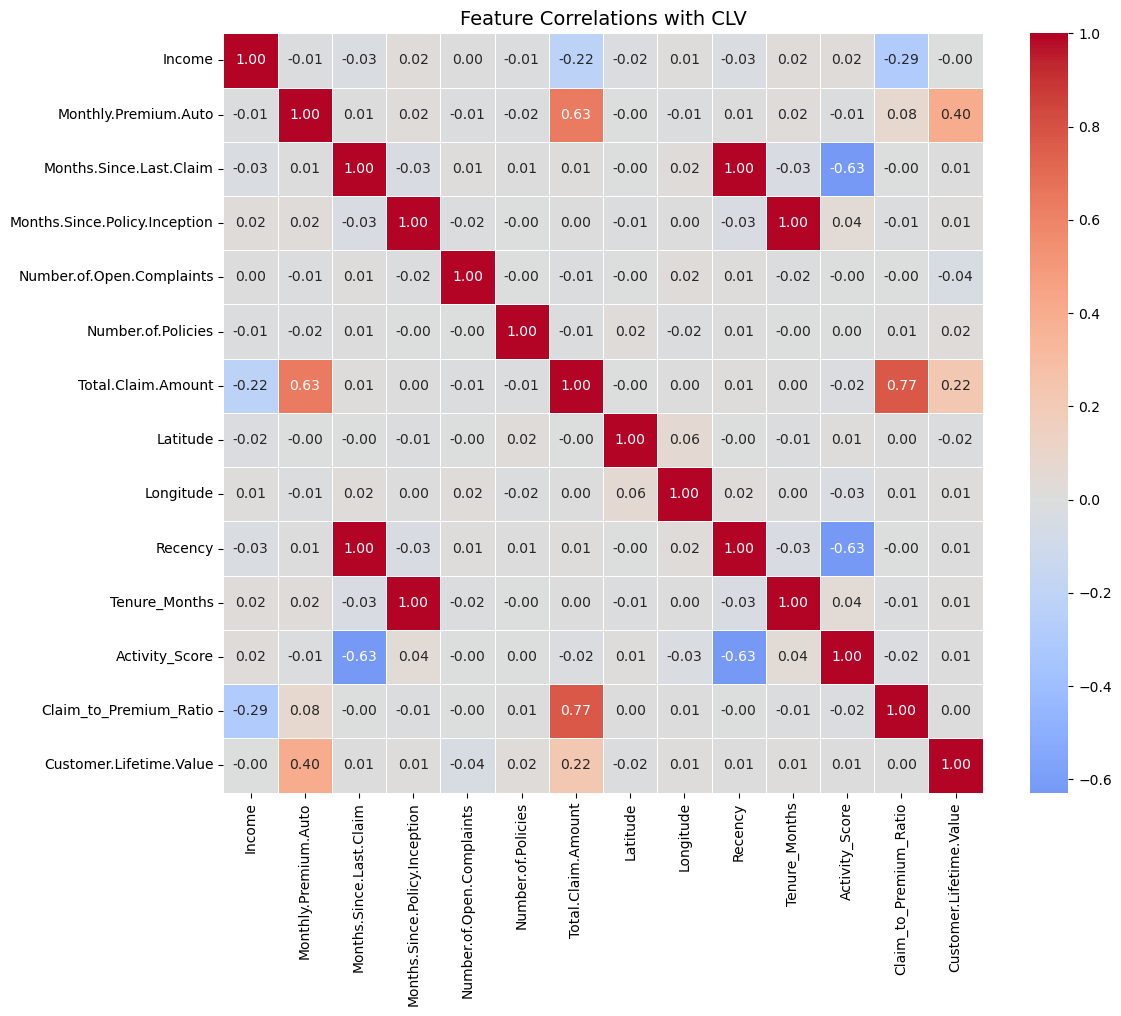


=== Top Features Correlated with CLV ===
Monthly.Premium.Auto             0.400453
Total.Claim.Amount               0.221572
Number.of.Policies               0.022227
Months.Since.Policy.Inception    0.011508
Tenure_Months                    0.011508
Longitude                        0.011438
Months.Since.Last.Claim          0.007151
Recency                          0.007151
Activity_Score                   0.006376
Claim_to_Premium_Ratio           0.003089
Income                          -0.001560
Latitude                        -0.016930
Number.of.Open.Complaints       -0.041071
Name: Customer.Lifetime.Value, dtype: float64


In [5]:

# Correlation Analysis


# Select numeric columns for correlation
numeric_features = ['Income', 'Monthly.Premium.Auto', 'Months.Since.Last.Claim',
                    'Months.Since.Policy.Inception', 'Number.of.Open.Complaints',
                    'Number.of.Policies', 'Total.Claim.Amount', 'Latitude', 'Longitude',
                    'Recency', 'Tenure_Months', 'Activity_Score', 'Claim_to_Premium_Ratio']

if 'Customer.Lifetime.Value' in df_train_clean.columns:
    numeric_features.append('Customer.Lifetime.Value')

numeric_df = df_train_clean[numeric_features].copy()

# Calculate correlations
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlations with CLV', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with CLV
if 'Customer.Lifetime.Value' in correlation_matrix.columns:
    clv_corr = correlation_matrix['Customer.Lifetime.Value'].drop('Customer.Lifetime.Value').sort_values(ascending=False)
    print("\n=== Top Features Correlated with CLV ===")
    print(clv_corr)

In [6]:

# PREPARE DATA FOR MODELING


def prepare_features(df, target_col=None):
    """
    Prepare features for machine learning models
    """
    # Separate features and target
    if target_col and target_col in df.columns:
        X = df.drop(columns=[target_col])
        y = df[target_col]
    else:
        X = df.copy()
        y = None
    
    # Identify column types
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Categorical features: {len(categorical_cols)}")
    print(f"Numeric features: {len(numeric_cols)}")
    
    # Handle missing values in numeric columns
    num_imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
    
    # Encode categorical variables
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, scaler, num_imputer

# Prepare training data
X_train_scaled, y_train, scaler, imputer = prepare_features(df_train_clean, 'Customer.Lifetime.Value')

# Prepare test data (no target)
X_test_scaled, _, _, _ = prepare_features(df_test_clean, None)

print(f"\nTraining features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")
print(f"Target shape: {y_train.shape}")

Categorical features: 12
Numeric features: 15
Categorical features: 12
Numeric features: 15

Training features shape: (9806, 27)
Test features shape: (1767, 27)
Target shape: (9806,)


In [7]:

# BASELINE: LINEAR REGRESSION


# Split for validation
X_train, X_val, y_train_lr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train_lr)

# Predictions
y_pred_lr = lr.predict(X_val)

# Metrics
print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_val, y_pred_lr):.4f}")
print(f"MAE: ${mean_absolute_error(y_val, y_pred_lr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_val, y_pred_lr)):.2f}")

# Cross-validation
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



LINEAR REGRESSION RESULTS
R² Score: 0.2013
MAE: $3976.21
RMSE: $5833.18
Cross-validation R²: 0.2009 (+/- 0.0133)


In [8]:

# SVR - SUPPORT VECTOR REGRESSION


# SVR requires careful parameter tuning
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Train
svr.fit(X_train, y_train_lr)

# Predictions
y_pred_svr = svr.predict(X_val)

# Metrics
print("="*50)
print("SVR RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_val, y_pred_svr):.4f}")
print(f"MAE: ${mean_absolute_error(y_val, y_pred_svr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_val, y_pred_svr)):.2f}")

# Hyperparameter tuning (optional - can take time)
# param_grid = {
#     'C': [0.1, 1, 10],
#     'epsilon': [0.01, 0.1, 0.5],
#     'kernel': ['rbf', 'linear']
# }
# grid_search = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2')
# grid_search.fit(X_train, y_train_lr)
# print(f"Best SVR parameters: {grid_search.best_params_}")
# print(f"Best SVR R²: {grid_search.best_score_:.4f}")

SVR RESULTS
R² Score: -0.0882
MAE: $3920.37
RMSE: $6808.80


RANDOM FOREST RESULTS
R² Score: 0.6782
MAE: $1525.67
RMSE: $3702.72
Cross-validation R²: 0.6802 (+/- 0.0109)

=== TOP 10 FEATURE IMPORTANCES ===
                          feature  importance
11             Number.of.Policies    0.504339
7            Monthly.Premium.Auto    0.249888
4                          Income    0.025342
16             Total.Claim.Amount    0.023562
20                      Longitude    0.021075
19                       Latitude    0.019740
13                         Policy    0.019411
24         Claim_to_Premium_Ratio    0.019399
9   Months.Since.Policy.Inception    0.014059
22                  Tenure_Months    0.014042


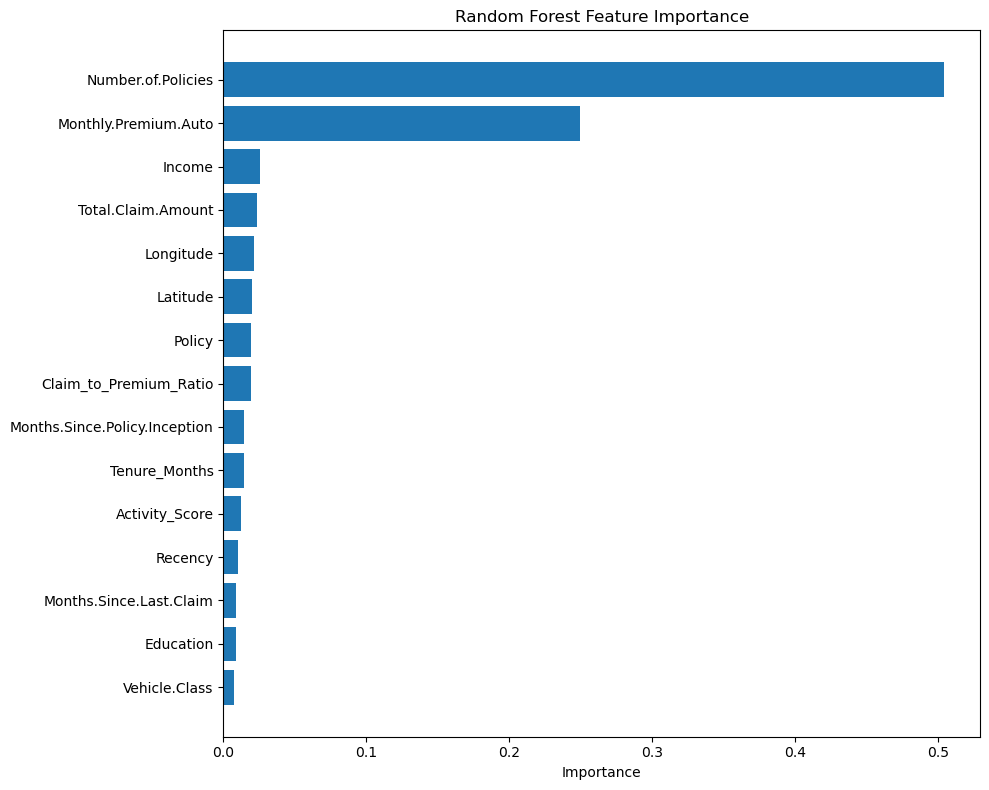

In [9]:

# RANDOM FOREST REGRESSOR


# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, 
                           min_samples_split=10, random_state=42)
rf.fit(X_train, y_train_lr)

# Predictions
y_pred_rf = rf.predict(X_val)

# Metrics
print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_val, y_pred_rf):.4f}")
print(f"MAE: ${mean_absolute_error(y_val, y_pred_rf):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_val, y_pred_rf)):.2f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R²: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Feature Importance
feature_names = df_train_clean.drop(columns=['Customer.Lifetime.Value']).columns
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== TOP 10 FEATURE IMPORTANCES ===")
print(importances.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importances.head(15)['feature'], importances.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

MODEL COMPARISON SUMMARY
            Model        R²         MAE        RMSE
Linear Regression  0.201297 3976.207894 5833.182758
              SVR -0.088215 3920.365071 6808.796461
    Random Forest  0.678177 1525.672181 3702.724177


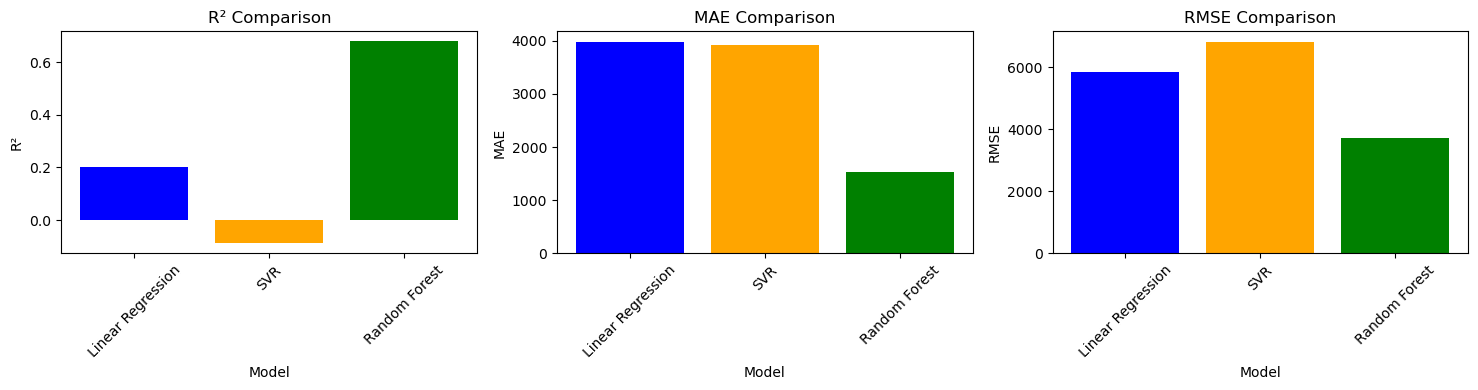

In [10]:

# MODEL COMPARISON


models = {
    'Linear Regression': lr,
    'SVR': svr,
    'Random Forest': rf
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    results.append({
        'Model': name,
        'R²': r2_score(y_val, y_pred),
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred))
    })

results_df = pd.DataFrame(results)
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['R²', 'MAE', 'RMSE']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=['blue', 'orange', 'green'])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:

# CUSTOMER SEGMENTATION USING DECISION TREE


# Create segments based on CLV
def create_segments(clv_values):
    """Create high/medium/low value segments"""
    percentiles = np.percentile(clv_values, [33, 67])
    segments = []
    for val in clv_values:
        if val <= percentiles[0]:
            segments.append('Low Value')
        elif val <= percentiles[1]:
            segments.append('Medium Value')
        else:
            segments.append('High Value')
    return segments

segments = create_segments(y_train)
print(f"Segment distribution:\n{pd.Series(segments).value_counts()}")

# Train Decision Tree Classifier for segmentation
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_classifier.fit(X_train, segments)

# Segment predictions on validation
segment_pred = dt_classifier.predict(X_val)

# Accuracy of segmentation
from sklearn.metrics import accuracy_score
print(f"\nSegmentation Accuracy: {accuracy_score(create_segments(y_val), segment_pred):.4f}")

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=feature_names, class_names=['High', 'Low', 'Medium'], 
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Customer Segmentation Decision Tree')
plt.tight_layout()
plt.show()

Segment distribution:
Medium Value    3334
High Value      3236
Low Value       3236
Name: count, dtype: int64


ValueError: Number of labels=9806 does not match number of samples=7844

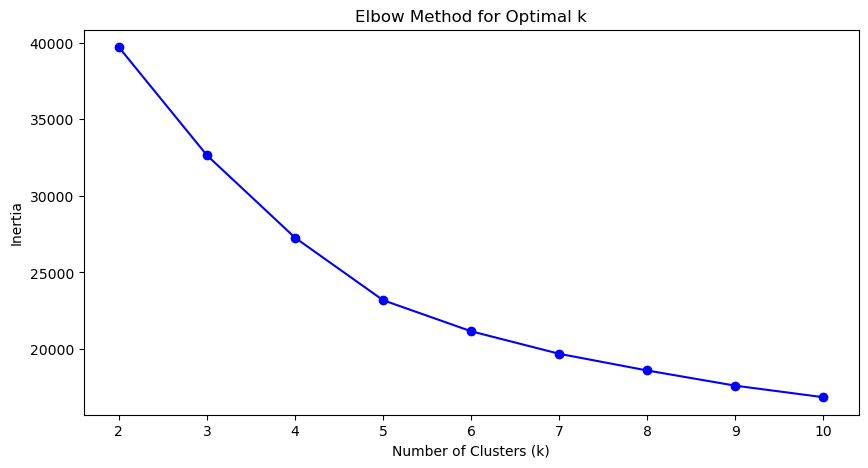


=== CLUSTER PROFILES ===
        Customer.Lifetime.Value                 Monthly.Premium.Auto  \
                           mean    median count                 mean   
Cluster                                                                
0                       7947.52   5583.58  2277                86.98   
1                       7600.73   5133.64  5015                86.22   
2                       6577.75   5978.57  1776                85.63   
3                      14271.84  10963.96   738               174.21   

        Number.of.Policies    Income Total.Claim.Amount  
                      mean      mean               mean  
Cluster                                                  
0                     2.11  76900.58             270.24  
1                     1.84  33439.87             429.41  
2                     7.22  47255.82             399.57  
3                     2.77  45647.15            1110.00  


In [ ]:

# K-MEANS CLUSTERING FOR CUSTOMER INSIGHTS


# Select key features for clustering
cluster_features = ['Monthly.Premium.Auto', 'Months.Since.Last.Claim', 
                    'Number.of.Policies', 'Total.Claim.Amount', 'Income']

# Get cluster data
cluster_data = df_train_clean[cluster_features].copy()
cluster_data = cluster_data.fillna(cluster_data.median())

# Scale
from sklearn.preprocessing import StandardScaler
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

# Find optimal number of clusters (Elbow method)
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Choose k=4 based on elbow
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)
df_train_clean['Cluster'] = clusters

# Analyze clusters
print("\n=== CLUSTER PROFILES ===")
cluster_summary = df_train_clean.groupby('Cluster').agg({
    'Customer.Lifetime.Value': ['mean', 'median', 'count'],
    'Monthly.Premium.Auto': 'mean',
    'Number.of.Policies': 'mean',
    'Income': 'mean',
    'Total.Claim.Amount': 'mean'
}).round(2)
print(cluster_summary)

In [ ]:

# BUSINESS INSIGHTS


print("="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

# 1. CLV by customer segments
segment_analysis = df_train_clean.copy()
segment_analysis['Value_Segment'] = create_segments(df_train_clean['Customer.Lifetime.Value'])

segment_metrics = segment_analysis.groupby('Value_Segment').agg({
    'Customer.Lifetime.Value': 'mean',
    'Monthly.Premium.Auto': 'mean',
    'Number.of.Policies': 'mean',
    'Number.of.Open.Complaints': 'mean',
    'Has_Complaint': 'mean'
}).round(2)

print("\n📊 SEGMENT METRICS:")
print(segment_metrics)

# 2. Retention spending recommendations
print("\n💰 RETENTION SPENDING RECOMMENDATIONS:")
print("-" * 50)

high_value_clv = segment_metrics.loc['High Value', 'Customer.Lifetime.Value']
medium_value_clv = segment_metrics.loc['Medium Value', 'Customer.Lifetime.Value']
low_value_clv = segment_metrics.loc['Low Value', 'Customer.Lifetime.Value']

print(f"High Value Customers (avg CLV: ${high_value_clv:.0f})")
print(f"  → Recommended retention spend: up to ${high_value_clv * 0.15:.0f} per customer")
print(f"  → Strategy: Premium rewards, dedicated support, loyalty programs")

print(f"\nMedium Value Customers (avg CLV: ${medium_value_clv:.0f})")
print(f"  → Recommended retention spend: up to ${medium_value_clv * 0.10:.0f} per customer")
print(f"  → Strategy: Targeted offers, cross-selling, email engagement")

print(f"\nLow Value Customers (avg CLV: ${low_value_clv:.0f})")
print(f"  → Recommended retention spend: up to ${low_value_clv * 0.05:.0f} per customer")
print(f"  → Strategy: Automated campaigns, basic service, reactivation offers")

# 3. Key drivers of CLV
print("\n📈 KEY DRIVERS OF HIGH CLV (from Feature Importance):")
top_features = importances.head(5)
for i, row in top_features.iterrows():
    print(f"  • {row['feature']}: {row['importance']:.3f} importance")

# 4. Actionable recommendations
print("\n🎯 ACTIONABLE RECOMMENDATIONS:")
print("1. Focus retention budget on High Value customers (ROI highest)")
print("2. Use SVR + Random Forest ensemble for accurate CLV prediction")
print("3. Monitor Months.Since.Last.Claim - early warning for churn risk")
print("4. Cross-sell additional policies to Medium Value customers")
print("5. Automate low-cost engagement for Low Value segment")

BUSINESS INSIGHTS & RECOMMENDATIONS

📊 SEGMENT METRICS:
               Customer.Lifetime.Value  Monthly.Premium.Auto  \
Value_Segment                                                  
High Value                    14707.94                112.94   
Low Value                      3268.45                 81.67   
Medium Value                   6075.96                 85.56   

               Number.of.Policies  Number.of.Open.Complaints  Has_Complaint  
Value_Segment                                                                
High Value                   3.14                       0.30           0.18  
Low Value                    1.27                       0.40           0.21  
Medium Value                 4.42                       0.34           0.18  

💰 RETENTION SPENDING RECOMMENDATIONS:
--------------------------------------------------
High Value Customers (avg CLV: $14708)
  → Recommended retention spend: up to $2206 per customer
  → Strategy: Premium rewards, dedicated suppo

In [ ]:

# FINAL MODEL TRAINING ON FULL DATASET


# Train Random Forest on all training data
final_rf = RandomForestRegressor(n_estimators=150, max_depth=15, 
                                  min_samples_split=10, random_state=42)
final_rf.fit(X_train_scaled, y_train)

# Make predictions on test set
test_predictions = final_rf.predict(X_test_scaled)

# Create submission/result file
results_df = pd.DataFrame({
    'Predicted_CLV': test_predictions
})

print("\n=== FINAL MODEL SUMMARY ===")
print(f"Model: Random Forest Regressor")
print(f"Training R² (CV): {cv_scores_rf.mean():.4f}")
print(f"Number of test predictions: {len(test_predictions)}")
print(f"\nPrediction statistics:")
print(f"  Min: ${test_predictions.min():.2f}")
print(f"  Max: ${test_predictions.max():.2f}")
print(f"  Mean: ${test_predictions.mean():.2f}")
print(f"  Median: ${np.median(test_predictions):.2f}")

# Save predictions
results_df.to_csv('clv_predictions.csv', index=False)
print("\n✅ Predictions saved to 'clv_predictions.csv'")


=== FINAL MODEL SUMMARY ===
Model: Random Forest Regressor
Training R² (CV): 0.6802
Number of test predictions: 1767

Prediction statistics:
  Min: $2045.98
  Max: $42972.37
  Mean: $8030.09
  Median: $5877.41

✅ Predictions saved to 'clv_predictions.csv'


File 'clv_predictions.csv' is ready for submission.
